# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">کتابخانه های مورد نیاز</div>

In [24]:
import pandas as pd 
import numpy as np 
from sklearn.datasets import fetch_lfw_people
import matplotlib.pylab as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">تنظیم استایل نمودار ها </div>

In [25]:
sns.set_style('whitegrid')

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">فراخوانی داده ها</div>

In [26]:
LFW = fetch_lfw_people(min_faces_per_person=50,resize=1)
X = LFW.data
Y = LFW.target
target_names = LFW.target_names
Image = LFW.images
print(X.shape)
print(target_names)

(1560, 11750)
['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Jacques Chirac' 'Jean Chretien'
 'John Ashcroft' 'Junichiro Koizumi' 'Serena Williams' 'Tony Blair']


# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">نمایش تعدادی از تصاویر </div>

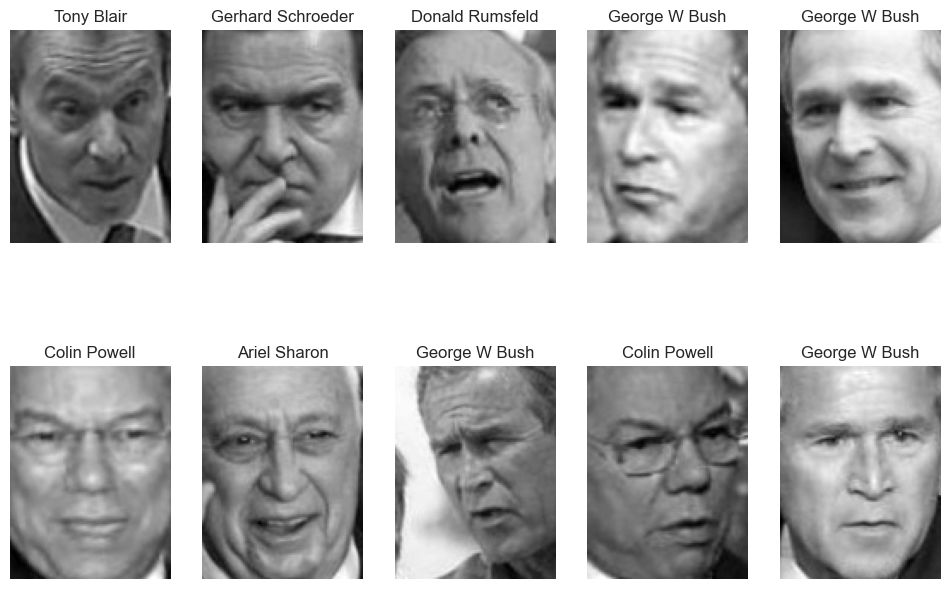

In [27]:
plt.figure(figsize=(12,8))
for i in range (10):
    plt.subplot(2,5,i+1)
    plt.imshow(Image[i],cmap = 'gray')
    plt.title(target_names[Y[i]])
    plt.axis('off')
plt.show()

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">استاندارد کردن داده ها</div>

<div dir = 'rtl'style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 22px; line-height: 1.8; text-align: justify;">

به منظور عدم تاثیر گذاری مقادیر بزرگ و احاطه کردن بعضی متغیر ها این عمل انجام شد 

</div>

In [28]:
scaler = StandardScaler()
X_tra = scaler.fit_transform(X)
print('mean:',np.mean(X_tra).round(3),'\nVar:',np.var(X_tra).round(3) )

mean: -0.0 
Var: 1.0


# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">رسم نمودار میزان توضیح پذیری مولفه های اصلی </div>

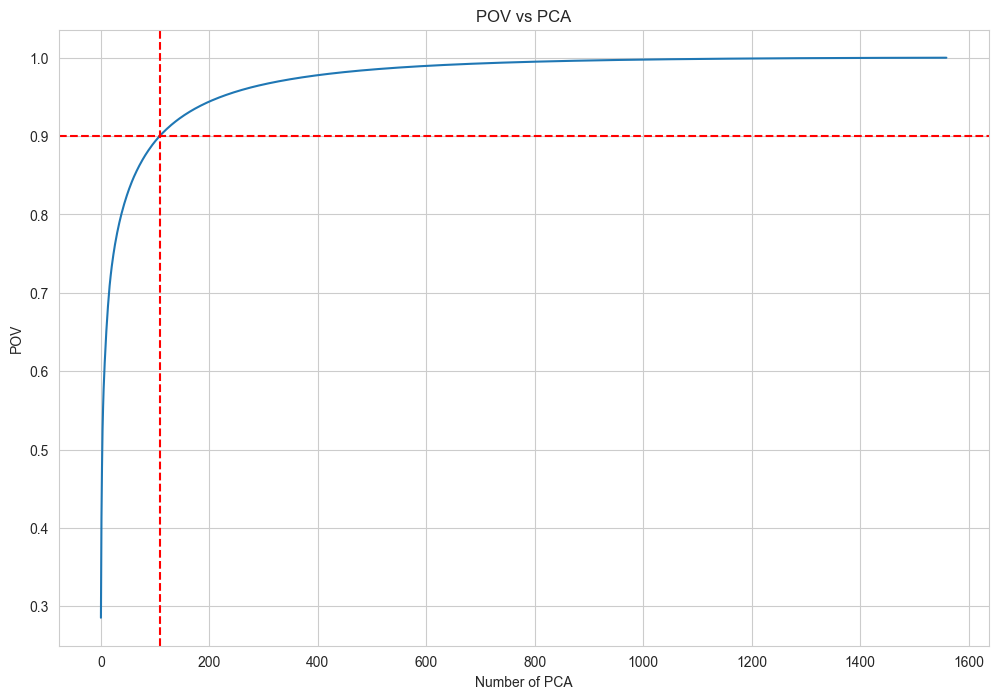

In [29]:
pca = PCA()
X_pca = pca.fit_transform(X_tra)
df_pca = pd.DataFrame({'EVR':pca.explained_variance_ratio_})
df_pca['POV'] = df_pca['EVR'].cumsum()
df_pca.head(10)
plt.figure(figsize=(12,8))
plt.plot(df_pca.index,df_pca['POV'])
plt.axhline(y = 0.9, color = 'red',linestyle = '--')
plt.axvline(np.argmax(df_pca['POV']>=0.9),color = 'red', linestyle = '--')
plt.title('POV vs PCA')
plt.xlabel('Number of PCA')
plt.ylabel('POV')
plt.show()

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">تعداد مولفه های اصلی استفاده شده در تحلیل </div>

In [30]:
np.argmax(df_pca['POV']>0.9)+1

110

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">اعمال مولفه های اصلی به داده های استاندارد شده </div>

In [31]:
pca_new = PCA(n_components=0.9)
X_pca_new = pca_new.fit_transform(X_tra)

In [32]:
n_comp = pca_new.components_.shape[0]
n_comp

110

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">الگوریتم <code> k_mean(k=10) </code></div>

In [33]:
k_means_10 = KMeans(n_clusters=10,n_init=20,random_state=42)
lab_kmeans_10 = k_means_10.fit_predict(X_pca_new)
print(lab_kmeans_10)
print('inertia:',k_means_10.inertia_,'\nsilhouette:',silhouette_score(X_pca_new,lab_kmeans_10))


[0 7 4 ... 6 5 7]
inertia: 9731297.0 
silhouette: 0.068367876


# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">محاسبه<code>inertia, silhouette</code>  های مختلف برای محاسبه <code>K</code>  بهینه </div>

In [34]:
inertia = []
silhouette = []
for i in range(2,21):
    k_means = KMeans(n_clusters=i,n_init=20,random_state=42)
    labs = k_means.fit_predict(X_pca_new)
    inertia.append(k_means.inertia_)
    silhouette.append(silhouette_score(X_pca_new,labs))

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">رسم نمودار <code>inertia(elbow method),silhouette</code> </div>

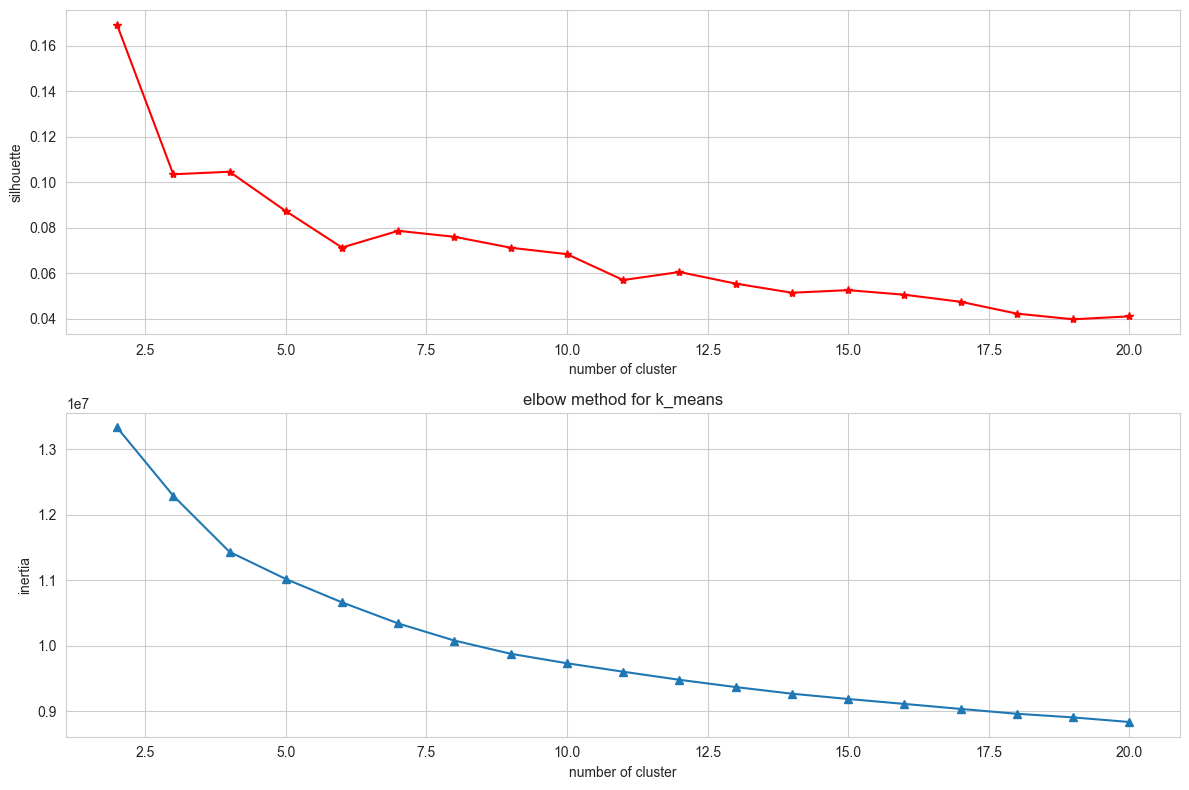

In [35]:
fig, axis = plt.subplots(2,1,figsize = (12,8))
axis[0].plot(range(2,21),silhouette,color = 'red',marker = '*',label = 'silhouette')
axis[0].set_xlabel('number of cluster')
axis[0].set_ylabel('silhouette')
axis[1].plot(range(2,21),inertia,marker = '^',label = 'inertia')
axis[1].set_title('elbow method for k_means')
axis[1].set_ylabel('inertia')
axis[1].set_xlabel('number of cluster')
plt.tight_layout()
plt.show()

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">انتخاب <code>K</code> بهینه </div>

<div dir = 'rtl'style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 22px; line-height: 1.8; text-align: justify;">
ابتدا با توجه نمودار inertia  تعداد خوشه های 4,5 کاندیدای انتخاب شدند که باتوجه نمودار silhouette  مقدار 4 به عنوان  k  بهینه انتخاب شده 

چند نکته k=2  به توجه به مفهوم تنها خوشه بندی پس زمینه و پیش زمینه غیر قابل استفاده است 

نکته بعدی به علت ذات الگوریتم که دوست دارد تعداد خوشه ها کمتر باشد و اینکه ما از PCA  استفاده کردیم که به علت وجود ویژگی های غیر خطی خوشه بندی ما کم دقت شده 

In [36]:
best_k = 4

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">برازش با <code>k</code>  بهینه</div>

In [37]:
k_means_best = KMeans(n_clusters=best_k,n_init=20,random_state=42)
k_means_best_labs = k_means_best.fit_predict(X_pca_new)

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">پیاده سازی الگوریتم <code>GMM</code> </div>

In [38]:
gmm = GaussianMixture(n_components=best_k,covariance_type='spherical',random_state=42)
gmm_labs = gmm.fit_predict(X_pca_new)
gmm.score(X_pca_new)

-388.1303330984283

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">آنالیز حساسیت </div>

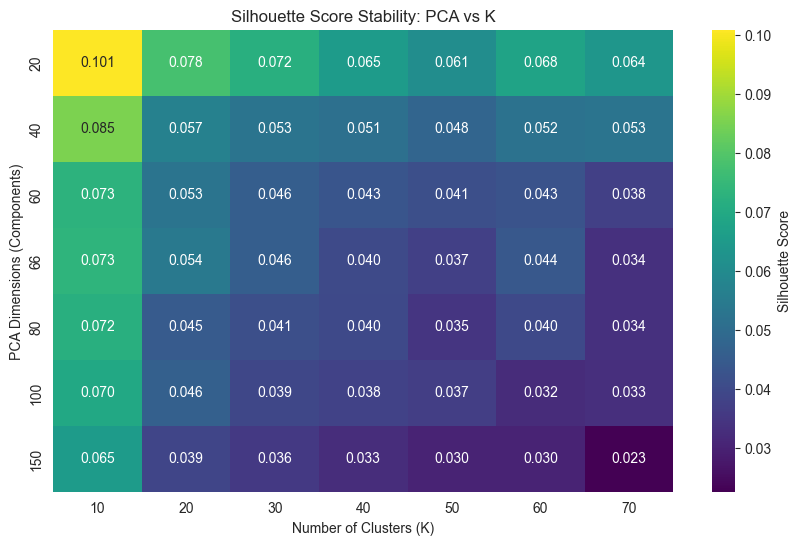

In [39]:
pca_dims = [20, 40, 60, 66, 80, 100, 150]
k_values = [10, 20, 30, 40, 50, 60, 70]
heatmap_result = []
for Pca in pca_dims:
    Pca = PCA(n_components=Pca)
    X_Temp = Pca.fit_transform(X_tra)
    for k in k_values:
        k_means_temp = KMeans(n_clusters=k,n_init=20,random_state=42)
        labs_temp = k_means_temp.fit_predict(X_Temp)
        heatmap_result.append(silhouette_score(X_Temp,labs_temp))
heatmap_result = np.asarray(heatmap_result).reshape(7,7)
df_results = pd.DataFrame(heatmap_result,index=pca_dims,columns=k_values)
plt.figure(figsize=(10, 6))
sns.heatmap(df_results, annot=True, fmt=".3f", cmap="viridis", cbar_kws={'label': 'Silhouette Score'})
plt.ylabel("PCA Dimensions (Components)")
plt.xlabel("Number of Clusters (K)")
plt.title("Silhouette Score Stability: PCA vs K")
plt.show()

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">ارزیابی مدل ها </div>

In [52]:
centers_kmeans = k_means.cluster_centers_
X_reconstructed_kmeans = centers_kmeans[labs]
recon_error_kmeans = np.mean(np.sum((X_pca_new - X_reconstructed_kmeans) ** 2, axis=1))
print("K-Means Reconstruction Error:", recon_error_kmeans)
means_gmm = gmm.means_
X_reconstructed_gmm = means_gmm[gmm_labs]
recon_error_gmm = np.mean(np.sum((X_pca_new - X_reconstructed_gmm) ** 2, axis=1))
print("GMM Reconstruction Error:", recon_error_gmm)
sil_kmeans = silhouette_score(X_pca_new, labs)
sil_gmm = silhouette_score(X_pca_new, gmm_labs)
print("Silhouette K-Means:", sil_kmeans)
print("Silhouette GMM:", sil_gmm)


K-Means Reconstruction Error: 5663.149
GMM Reconstruction Error: 7380.178330920915
Silhouette K-Means: 0.041001674
Silhouette GMM: 0.093836166


In [41]:
print("-" * 40)
print(f"Selected K: {best_k}")
print(f"K-Means Inertia: {k_means_best.inertia_:.2f}")
print("-" * 40)
print(f"GMM Log-Likelihood: {gmm.score(X_pca_new) * len(X_pca_new):.2f} (Total)") 
print(f"GMM AIC : {gmm.aic(X_pca_new):.2f}")
print(f"GMM BIC : {gmm.bic(X_pca_new):.2f}")

----------------------------------------
Selected K: 4
K-Means Inertia: 11431831.00
----------------------------------------
GMM Log-Likelihood: -605483.32 (Total)
GMM AIC : 1211860.64
GMM BIC : 1214253.18


# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">ساخت <code>eigen face</code></div>

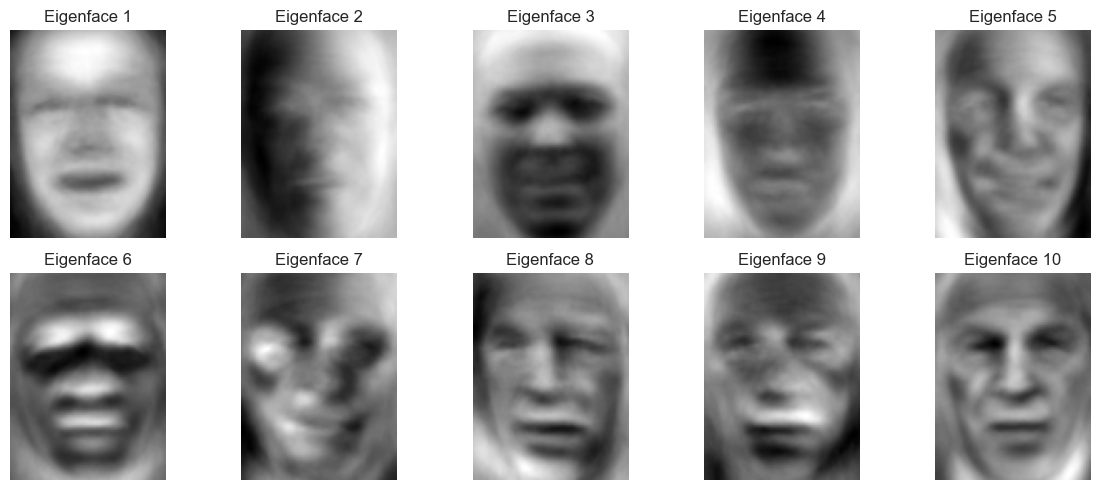

In [42]:
h, w = Image.shape[1:]
n_comp = pca_new.components_.shape[0]
eigenfaces = pca_new.components_.reshape((n_comp, h, w))
n_eigenfaces = 10
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[i], cmap='gray')
    ax.set_title(f"Eigenface {i+1}")
    ax.axis('off')

plt.tight_layout()
plt.show()


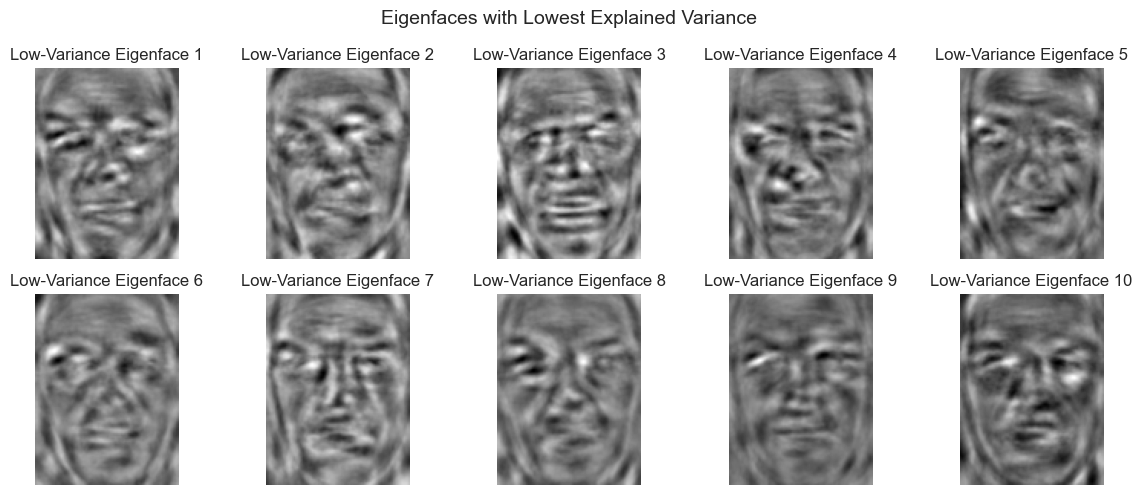

In [43]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[-(i + 1)], cmap='gray')
    ax.set_title(f"Low-Variance Eigenface {i + 1}")
    ax.axis('off')

plt.suptitle("Eigenfaces with Lowest Explained Variance", fontsize=14)
plt.tight_layout()
plt.show()